In [1]:
from inspectre import Inspectre, ray_sampling
import numpy as np
from scipy import integrate as it
import matplotlib.pyplot as plt
from scipy.interpolate import InterpolatedUnivariateSpline as IUS
from scipy.interpolate import CubicSpline

In [2]:
a = 0.5
p = 10.0
e = 0.2
x = 1
mass = 1.0
err = 1e-15
mode="equatorial"

insp = Inspectre(
    spin=a,
    semilatus_rectum=p,
    eccentricity=e,
    x=x,
    mass=mass,
    err=err,
    mode=mode
)

In [3]:
N=14
insp.generate_equatorial_trajectory(num_pts=2**N)
traj = insp.trajectory.copy()

In [4]:
attributes = set(dir(insp.es._ef._ctx)).difference(set(['this','thisown','xp','M','a']))

In [5]:
getattr(insp.es._ef._ctx, 'a')

0.5

In [7]:
coeff_array = []
zipper = zip(traj['lambda'], traj['t'], traj['r'], traj['theta'], traj['phi'], traj['ur'])
for lam, t, r, th, ph, ur in zipper:
    insp.set_particle(r, th, ph, ur)
    coeff_array.append([insp.es._ef._ctx.A0060,insp.es._ef._ctx.A0061])

coeff_array = np.array(coeff_array)

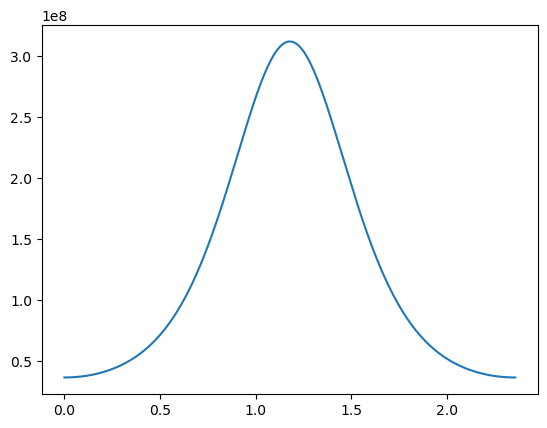

In [8]:
plt.plot(traj['lambda'], coeff_array.T[0])